# The Multi-Needle Problem: Agentic Retrieval and Reasoning Fails to Scale

**Mehrab Modi** | April 2026 | [github.com/mehrabmodi1/agentic-retrieval](https://github.com/mehrabmodi1/agentic-retrieval)

Memory is at the core of who we are, how we think. Our ability to learn things, recall facts or reason about them is a complex series of discrete, cognitive operations we often take for granted. Over the last month or so, my work has involved building scaffolding for very capable coding agents to build high-quality code. For a coding-agent to work well, it too needs to retrieve facts from a large body of rememebered items (the code-base on disk) and then reason about them. This article is about an experiment I ran over the last week and a half, where I tried to systematically challenge agents over a range of retrieval and reasoning difficulties. And I found that even with Opus 4.6, in certain ranges of the difficulty parameter space, the agents mostly failed.  

The setup: I generated text corpora — some styled as Python repositories, others as noir detective fiction — and hid facts inside them. Then I asked a Claude Code agent to find those facts. Three flavours of task, each harder than the last. **Single-needle**: find one specific fact buried in the corpus. **Multi-chain**: follow a trail of cross-references across files to reach a final answer. **Multi-reasoning**: locate several scattered clues and piece them together to answer the question. I varied corpus size from 20k to 800k tokens, the number of items to find from 2 to 16, and how directly the question references the clues — from exact keyword matches to contextual paraphrases. 336 experimental conditions, each run 3 times. On top of that, I ran a smaller focused comparison — the same representative-parameter subset — with two alternative model-configurations: Sonnet 4.6 at effort=max (more test-time compute), and Opus 4.6 (Claude's strongest model) at effort=low.

Two headlines. The first: **more compute rescues chain-following, but not information-synthesis.** Sonnet 4.6 at effort=low reaches only ~60% on multi-chain; dial effort up to max and it climbs to ~100% — essentially matching Opus. For chain-following tasks, the agent just needed room to persist. Multi-reasoning tells a different story. When the agent has to find many items, hold them all in memory, and reason across them, neither increased compute nor model upgrade help: at n=16, every configuration I tried collapses to very low accuracy or completeness. This isn't a Sonnet problem or a low-effort problem. It looks like a general limitation of today's coding agents.

We are starting to give LLM-powered agents more agency in our world; from building code to planning itineraries. We should know the limits of their cognitive limitations. If simultaneous reasoning across ~8-16 retrieved facts is hard, we should design our code-bases or travel-criteria with that in mind. I know I would find such a task hard myself. But as models and agent harnesses race to get better, we can plan and design our systems to make the most of their capabilities. Token-maxing is a perverse metric after all. We should be maximising value/token first. The git repository I've shared with this article can be used to re-run these experiments, or even design new ones as agents get better and need harder challenges. I know I will keep returning to it (watch this space!) - and hope it provides value to others too.

A huge shoutout to Locus, my employer, for encouraging excitement about and experimentation with these ever-changing tools.

## What the tasks look like

To make this concrete, here are examples from each experiment type — one from the noir fiction corpus, one from the Python corpus.

**Single needle** — find one fact:
> *"According to Deke the bartender's witness statement, what location did the older man whisper to the kid at The Crimson Door Lounge?"* → **The Starlight Motor Inn, room 14**

> *"What is the value of `MAX_TASK_RETRY_DELAY` defined in this codebase?"* → **47**

**Multi-chain** — starting from a named location in the corpus, follow cross-references to reach a final answer. The question names the start of the chain, but not the intermediate steps — the agent has to discover those itself:
> *"Starting from the matchbook Catherine left with Eleanor Walsh, follow the chain to Deke at The Crimson Door. What address is written on the envelope Deke has been holding?"* → **Warehouse 9, Pier 41, north dock**
>
> Eleanor produces a matchbook from Catherine — it reads *The Crimson Door Lounge*. At The Crimson Door, the bartender Deke reveals a sealed envelope Catherine left with him. The address on it is the answer.

> *"Starting from `ROUTE_CHAIN_START` in `api/routes.md`, follow the chain of config references through each file. What is the final value that the chain ultimately resolves to?"* → **XK-7734-FINAL**
>
> The agent has to discover: `routes.md` points to `api/middleware.py` → `api/validators.py` → `api/pagination.py` → `api/serializers.py` → ... → `workers/email_worker.py` where the terminal value lives. Eight hops, each in a different file.

**Multi-reasoning** — find scattered clues across the corpus and synthesise them into a coherent answer. Unlike multi-chain, the agent can't follow a trail — it has to hold all the clues in memory and reason across them:
> *"Based on the evidence collected across the investigation, what time window was the crime committed in?"*
>
> Three facts are scattered across different files. A pharmacy receipt timestamped 8:47 PM confirms the victim was alive. A neighbour heard him until about 9:45 PM. The coroner's note says rigor onset suggests no more than four hours before the body was discovered at 11 PM. The agent has to find all three, recognise they constrain the same window, and conclude: **between 9:45 PM and 11:00 PM**.

> *"What is the total maximum memory allocation across all cache layers (`L1_CACHE_SIZE_MB`, `L2_CACHE_SIZE_MB`, `L3_CACHE_SIZE_MB`)?"*
>
> Each constant lives in a different config file. The agent has to find all three values (512, 2048, 8192) and sum them: **10,752 MB**.

In [1]:
BATCH_NAME = "full-sweep__20260408T130426"
WORKSPACE_DIR = "../workspace"

In [2]:
from pathlib import Path
from agent_retrieval.analysis.loader import load_batch_results
df = load_batch_results(BATCH_NAME, Path(WORKSPACE_DIR))

## Experiment Summary

In [3]:
summary = df.groupby("experiment_type").agg(
    n=("weighted_score", "count"),
    profiles=("content_profile", lambda x: ", ".join(sorted(x.unique()))),
    corpus_sizes=("corpus_token_count", lambda x: ", ".join(f"{int(s)//1000}k" for s in sorted(x.unique()))),
    n_items=("n_items", lambda x: ", ".join(str(int(v)) for v in sorted(x.dropna().unique())) or "—"),
    clarity_levels=("reference_clarity", lambda x: ", ".join(sorted(x.unique()))),
).reindex(["single_needle", "multi_chain", "multi_reasoning"])

summary.index = ["single needle", "multi-chain", "multi-reasoning"]
summary.columns = ["n", "content profiles", "corpus sizes", "n-items", "reference clarity"]
display(summary)

,n,content profiles,corpus sizes,n-items,reference clarity
single needle,143,"noir_fiction, python_repo","20k, 40k, 160k, 800k",—,"contextual, exact, synonym"
multi-chain,407,"noir_fiction, python_repo","20k, 40k, 160k, 800k","2, 8, 16","contextual, exact, synonym"
multi-reasoning,326,"noir_fiction, python_repo","20k, 40k, 160k, 800k","2, 8, 16","contextual, exact, synonym"


## Figure 0: Model and Effort Comparison

Before diving into the full parameter sweep, a headline comparison. We ran a focused subset of the hardest conditions (python repo, hard discriminability, synonym references, corpus sizes 40k and 800k) across three configurations:

- **Sonnet 4.6, effort=low** — the full sweep configuration
- **Sonnet 4.6, effort=max** — same model, maximum test-time compute
- **Opus 4.6, effort=low** — stronger model, minimal test-time compute

The left panel shows n=2 items (the easier end); the right panel shows n=16 (the harder end). Single needle has no n-items dimension, so it appears in both panels identically.

**Panels:**
- **(a)** n=2 items. All three configs score well on single needle and multi-reasoning. The main separation is multi-chain, where effort=max and Opus both outperform Sonnet low substantially.
- **(b)** n=16 items. Multi-reasoning collapses to near zero for all three configs — no amount of model power or compute budget rescues it. Multi-chain is where the story diverges: Sonnet low drops to ~50%, while effort=max and Opus hold above 90%. More compute or a stronger model helps chain-following but not synthesis.

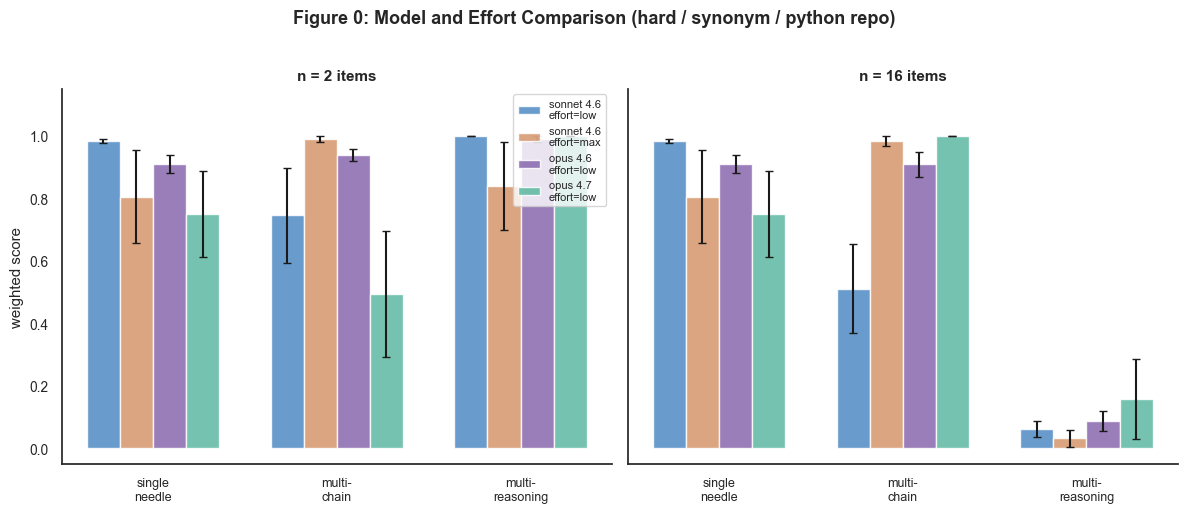

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np
from pathlib import Path
import yaml as _yaml

sns.set_theme(style="white", font_scale=0.9)

# --- Figure 0: Model and Effort Comparison ---

COMPARISON_BATCHES = {
    "sonnet 4.6\neffort=low": "full-sweep__20260408T130426",
    "sonnet 4.6\neffort=max": "hard-synonym-subset_sonnet-4-6_effort-max__20260413T103017",
    "opus 4.6\neffort=low": "hard-synonym-subset_opus-4-6_effort-low__20260413T112314",
    "opus 4.7\neffort=low": "hard-synonym-subset_opus-4-7_effort-low__20260418T055310",
}

CONFIG_COLORS = {
    "sonnet 4.6\neffort=low": "#4F8BC4",
    "sonnet 4.6\neffort=max": "#D4956A",
    "opus 4.6\neffort=low": "#8868AE",
    "opus 4.7\neffort=low": "#5DB8A2",
}

# Collect scores per (config, experiment_type, n_items)
fig0_data = {}
for config_label, batch_name in COMPARISON_BATCHES.items():
    jdir = Path(f"../workspace/judge/judgements/{batch_name}")
    for v in sorted(jdir.rglob("*.yaml")):
        data = _yaml.safe_load(v.read_text())
        pid = data["parametrisation_id"]

        if "python_repo" not in pid or "hard" not in pid or "synonym" not in pid:
            continue
        if "40k" not in pid and "800k" not in pid:
            continue

        et = pid.split("__")[0]
        n_items = None
        if et in ("multi_chain", "multi_reasoning"):
            for part in pid.split("__"):
                if part.startswith("n") and part[1:].isdigit():
                    n_items = int(part[1:])
            if n_items not in (2, 16):
                continue

        key = (config_label, et, n_items)
        fig0_data.setdefault(key, []).append(data["weighted_score"])

# Build the plot
exp_types = ["single_needle", "multi_chain", "multi_reasoning"]
exp_labels_short = {"single_needle": "single\nneedle", "multi_chain": "multi-\nchain", "multi_reasoning": "multi-\nreasoning"}
config_labels = list(COMPARISON_BATCHES.keys())
n_configs = len(config_labels)
bar_width = 0.18

fig0, axes0 = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for panel_idx, n_val in enumerate([2, 16]):
    ax = axes0[panel_idx]
    x = np.arange(len(exp_types))

    for ci, config_label in enumerate(config_labels):
        means = []
        stds = []
        for et in exp_types:
            ni = None if et == "single_needle" else n_val
            scores = fig0_data.get((config_label, et, ni), [])
            means.append(np.mean(scores) if scores else 0)
            stds.append(np.std(scores) / np.sqrt(len(scores)) if scores else 0)

        offset = (ci - (n_configs - 1) / 2) * bar_width
        ax.bar(
            x + offset, means, bar_width, yerr=stds, capsize=3,
            color=CONFIG_COLORS[config_label], alpha=0.85,
            label=config_label if panel_idx == 0 else None,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([exp_labels_short[et] for et in exp_types], fontsize=9)
    ax.set_ylim(-0.05, 1.15)
    ax.set_title(f"n = {n_val} items", fontsize=11, fontweight="bold")
    if panel_idx == 0:
        ax.set_ylabel("weighted score")
    sns.despine(ax=ax)

axes0[0].legend(fontsize=8, loc="upper right")
fig0.suptitle("Figure 0: Model and Effort Comparison (hard / synonym / python repo)", fontsize=13, fontweight="bold", y=1.02)
fig0.tight_layout()
plt.show()

## Figure 1: Accuracy and Completeness vs Corpus Size

**(a, b)** Mean correctness (solid) vs completeness (dashed) by corpus size, for python repo and noir fiction.
**(c, d)** Weighted score by reference clarity (exact / synonym / contextual). Low-opacity lines show individual clarity levels; bold lines show the mean.
**(e, f)** Weighted score by number of items to find (multi-chain and multi-reasoning only).

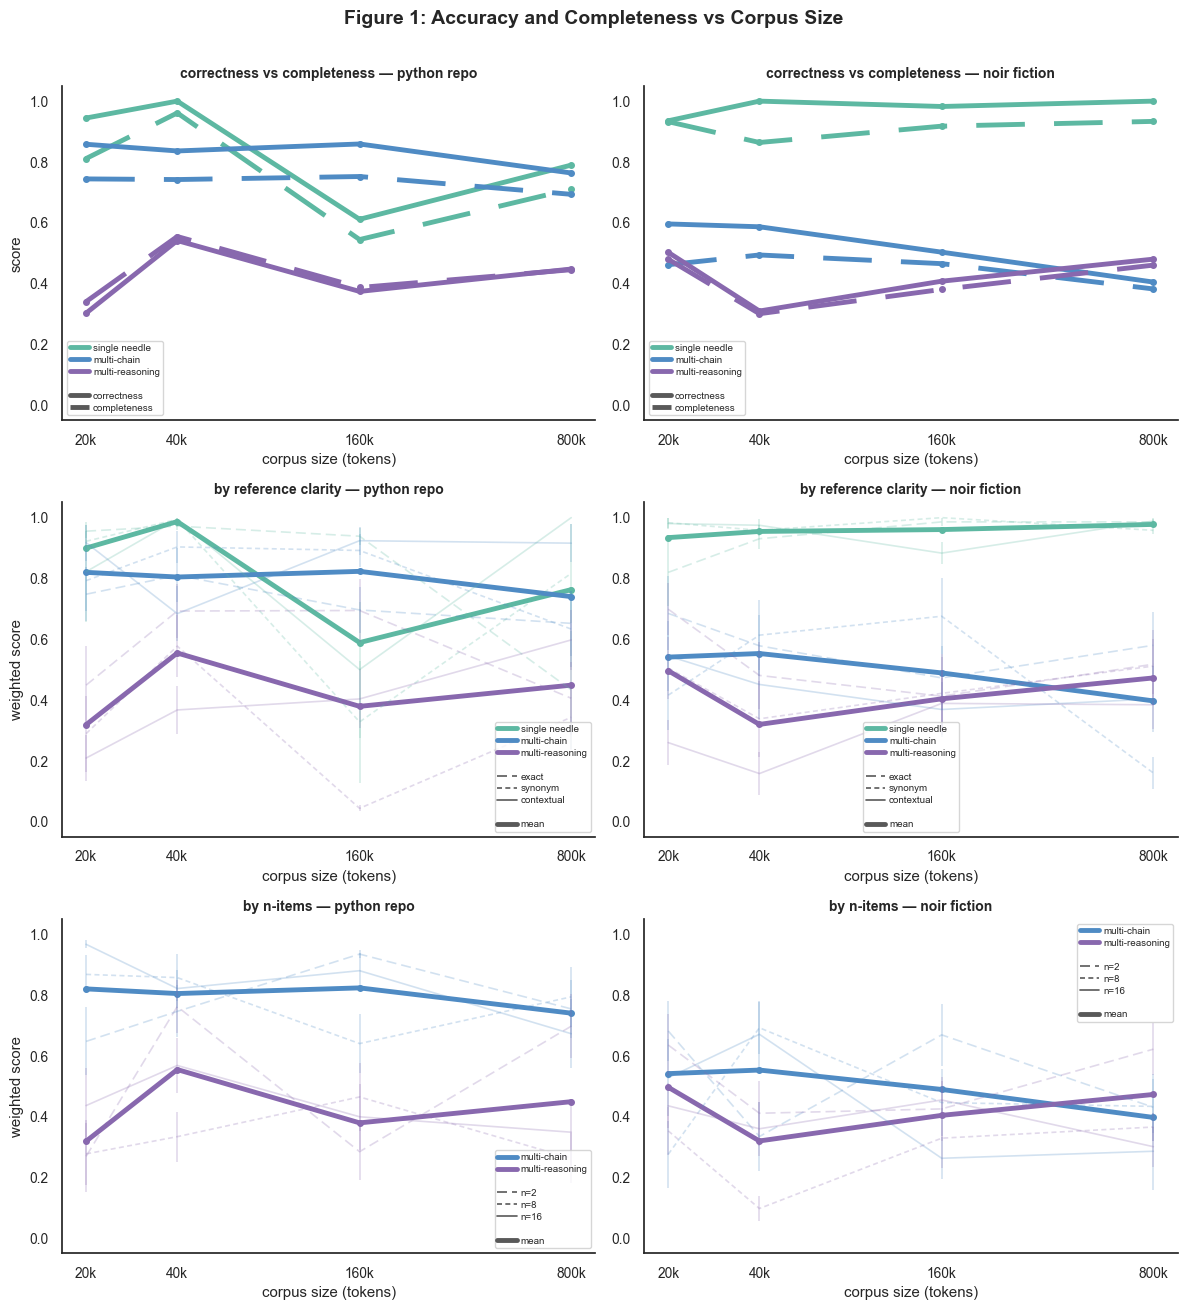

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="white", font_scale=0.9)

EXP_ORDER = ["single_needle", "multi_chain", "multi_reasoning"]
EXP_LABELS = {"single_needle": "single needle", "multi_chain": "multi-chain", "multi_reasoning": "multi-reasoning"}
PROFILES = ["python_repo", "noir_fiction"]
PROFILE_LABELS = {"noir_fiction": "noir fiction", "python_repo": "python repo"}
CLARITY_ORDER = ["exact", "synonym", "contextual"]
N_ITEMS_ORDER = [2, 8, 16]

# Cohesive teal → blue → purple (light → dark ≈ easy → hard task)
EXP_PALETTE = {"single_needle": "#5DB8A2", "multi_chain": "#4F8BC4", "multi_reasoning": "#8868AE"}

# Warm earth/amber palette for tools (distinct from cool experiment colours)
TOOL_PALETTE = ["#E07B54", "#5BA37C", "#4A90C4", "#C4A24E", "#A0A0A0"]  # grep, glob, read, subagent, other

CLARITY_DASHES = {"exact": (6, 3), "synonym": (3, 2), "contextual": ""}
NITEMS_DASHES = {2: (6, 3), 8: (3, 2), 16: ""}

DETAIL_ALPHA = 0.25
MEAN_ALPHA = 1.0
MEAN_LW = 3.5
DETAIL_LW = 1.2

CORPUS_SIZES = [20_000, 40_000, 160_000, 800_000]
CORPUS_LABELS = ["20k", "40k", "160k", "800k"]

def set_corpus_xticks(ax):
    ax.set_xscale("log")
    ax.set_xticks(CORPUS_SIZES)
    ax.set_xticklabels(CORPUS_LABELS)
    ax.xaxis.set_minor_locator(mticker.NullLocator())

def _dash_kwargs(dash):
    """Return linestyle/dashes kwargs, avoiding passing None to matplotlib."""
    if dash:
        return {"linestyle": "--", "dashes": dash}
    return {"linestyle": "-"}

def add_legend(ax, mode="clarity"):
    type_handles = [
        mlines.Line2D([], [], color=EXP_PALETTE[e], linewidth=3.5, linestyle="-", label=EXP_LABELS[e])
        for e in EXP_ORDER if mode == "clarity" or e in ["multi_chain", "multi_reasoning"]
    ]
    spacer = mlines.Line2D([], [], linestyle="none", label="")
    if mode == "clarity":
        series_handles = [
            mlines.Line2D([], [], color="0.35", linewidth=1.2,
                          label=c, **_dash_kwargs(CLARITY_DASHES[c]))
            for c in CLARITY_ORDER
        ]
    else:
        series_handles = [
            mlines.Line2D([], [], color="0.35", linewidth=1.2,
                          label=f"n={n}", **_dash_kwargs(NITEMS_DASHES[n]))
            for n in N_ITEMS_ORDER
        ]
    mean_handle = mlines.Line2D([], [], color="0.35", linewidth=3.5, linestyle="-", label="mean")
    all_handles = type_handles + [spacer] + series_handles + [spacer, mean_handle]
    ax.legend(handles=all_handles, fontsize=7, loc="best", ncol=1,
              handletextpad=0.4, borderpad=0.3, labelspacing=0.3)

def plot_series(ax, df, y_col, exp_types, mode="clarity"):
    items = CLARITY_ORDER if mode == "clarity" else N_ITEMS_ORDER
    dashes = CLARITY_DASHES if mode == "clarity" else NITEMS_DASHES
    group_col = "reference_clarity" if mode == "clarity" else "n_items"

    for exp_type in exp_types:
        color = EXP_PALETTE[exp_type]
        sub_all = df[df["experiment_type"] == exp_type]
        if mode == "nitems":
            sub_all = sub_all.dropna(subset=["n_items"])
        if sub_all.empty:
            continue

        for item in items:
            isub = sub_all[sub_all[group_col] == item]
            if isub.empty:
                continue
            stats = isub.groupby("corpus_token_count")[y_col].agg(["mean", "std", "count"]).reset_index()
            stats["sem"] = stats["std"] / np.sqrt(stats["count"])
            ax.errorbar(
                stats["corpus_token_count"], stats["mean"], yerr=stats["sem"].fillna(0),
                color=color, linewidth=DETAIL_LW, capsize=0, markersize=0,
                alpha=DETAIL_ALPHA, **_dash_kwargs(dashes[item]),
            )

        mean_stats = sub_all.groupby("corpus_token_count")[y_col].agg(["mean"]).reset_index()
        ax.plot(
            mean_stats["corpus_token_count"], mean_stats["mean"],
            color=color, linewidth=MEAN_LW, alpha=MEAN_ALPHA, marker="o", markersize=4,
        )

# --- Figure 1: Accuracy and Completeness vs Corpus Size (3x2) ---
fig, axes = plt.subplots(3, 2, figsize=(12, 13))

# Row 1: correctness vs completeness (mean only, all experiment types)
SCORE_DASHES = {"correctness": "", "completeness": (10, 6)}
for col_idx, profile in enumerate(PROFILES):
    ax = axes[0, col_idx]
    sub = df[df["content_profile"] == profile]
    for exp_type in EXP_ORDER:
        color = EXP_PALETTE[exp_type]
        esub = sub[sub["experiment_type"] == exp_type]
        if esub.empty:
            continue
        for metric, dash in SCORE_DASHES.items():
            col = f"score_{metric}"
            if col not in esub.columns:
                continue
            stats = esub.dropna(subset=[col]).groupby("corpus_token_count")[col].mean().reset_index()
            ax.plot(
                stats["corpus_token_count"], stats[col],
                color=color, linewidth=MEAN_LW, alpha=MEAN_ALPHA, marker="o", markersize=4,
                **_dash_kwargs(dash),
            )
    ax.set_ylim(-0.05, 1.05)
    set_corpus_xticks(ax)
    ax.set_title(f"correctness vs completeness — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("score")
    ax.set_xlabel("corpus size (tokens)")
    type_handles = [
        mlines.Line2D([], [], color=EXP_PALETTE[e], linewidth=3.5, linestyle="-", label=EXP_LABELS[e])
        for e in EXP_ORDER
    ]
    spacer = mlines.Line2D([], [], linestyle="none", label="")
    metric_handles = [
        mlines.Line2D([], [], color="0.35", linewidth=MEAN_LW, linestyle="-", label="correctness"),
        mlines.Line2D([], [], color="0.35", linewidth=MEAN_LW, linestyle="--", dashes=(10, 6), label="completeness"),
    ]
    ax.legend(handles=type_handles + [spacer] + metric_handles, fontsize=7, loc="best",
              handletextpad=0.4, borderpad=0.3, labelspacing=0.3)
    sns.despine(ax=ax)

# Row 2: by reference clarity
for col_idx, profile in enumerate(PROFILES):
    ax = axes[1, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "weighted_score", EXP_ORDER, mode="clarity")
    ax.set_ylim(-0.05, 1.05)
    set_corpus_xticks(ax)
    ax.set_title(f"by reference clarity — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("weighted score")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="clarity")
    sns.despine(ax=ax)

# Row 3: by n-items
for col_idx, profile in enumerate(PROFILES):
    ax = axes[2, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "weighted_score", ["multi_chain", "multi_reasoning"], mode="nitems")
    ax.set_ylim(-0.05, 1.05)
    set_corpus_xticks(ax)
    ax.set_title(f"by n-items — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("weighted score")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="nitems")
    sns.despine(ax=ax)

fig.suptitle("Figure 1: Accuracy and Completeness vs Corpus Size", fontsize=14, fontweight="bold", y=1.005)
fig.tight_layout()
plt.show()

## Figure 2: Session Cost vs Corpus Size

Y-axis shows total session cost in USD as reported by the Claude Agent SDK, including subagent token spend.

**(a, b)** Session cost by reference clarity.
**(c, d)** Session cost by number of items.

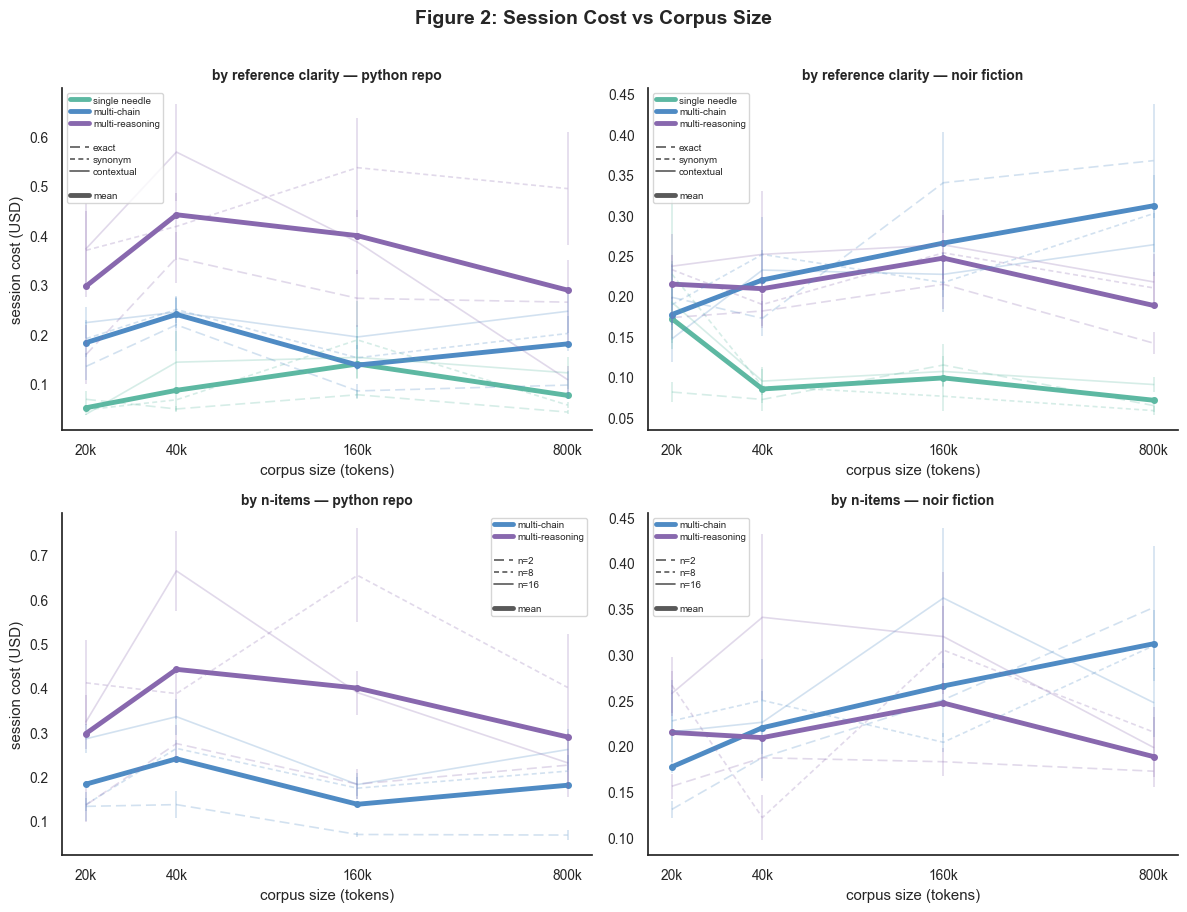

In [6]:
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 9))

# Row 1: by reference clarity
for col_idx, profile in enumerate(PROFILES):
    ax = axes2[0, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_cost_usd", EXP_ORDER, mode="clarity")
    set_corpus_xticks(ax)
    ax.set_title(f"by reference clarity — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("session cost (USD)")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="clarity")
    sns.despine(ax=ax)

# Row 2: by n-items
for col_idx, profile in enumerate(PROFILES):
    ax = axes2[1, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_cost_usd", ["multi_chain", "multi_reasoning"], mode="nitems")
    set_corpus_xticks(ax)
    ax.set_title(f"by n-items — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("session cost (USD)")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="nitems")
    sns.despine(ax=ax)

fig2.suptitle("Figure 2: Session Cost vs Corpus Size", fontsize=14, fontweight="bold", y=1.01)
fig2.tight_layout()
plt.show()

## Figure 3: Tool Calls vs Corpus Size

Total tool calls per run (grep + glob + read + subagent + other). Bash commands are classified into the corresponding functional category.

**(a, b)** Mean total tool calls by reference clarity.
**(c, d)** Mean total tool calls by number of items (multi-chain and multi-reasoning only).

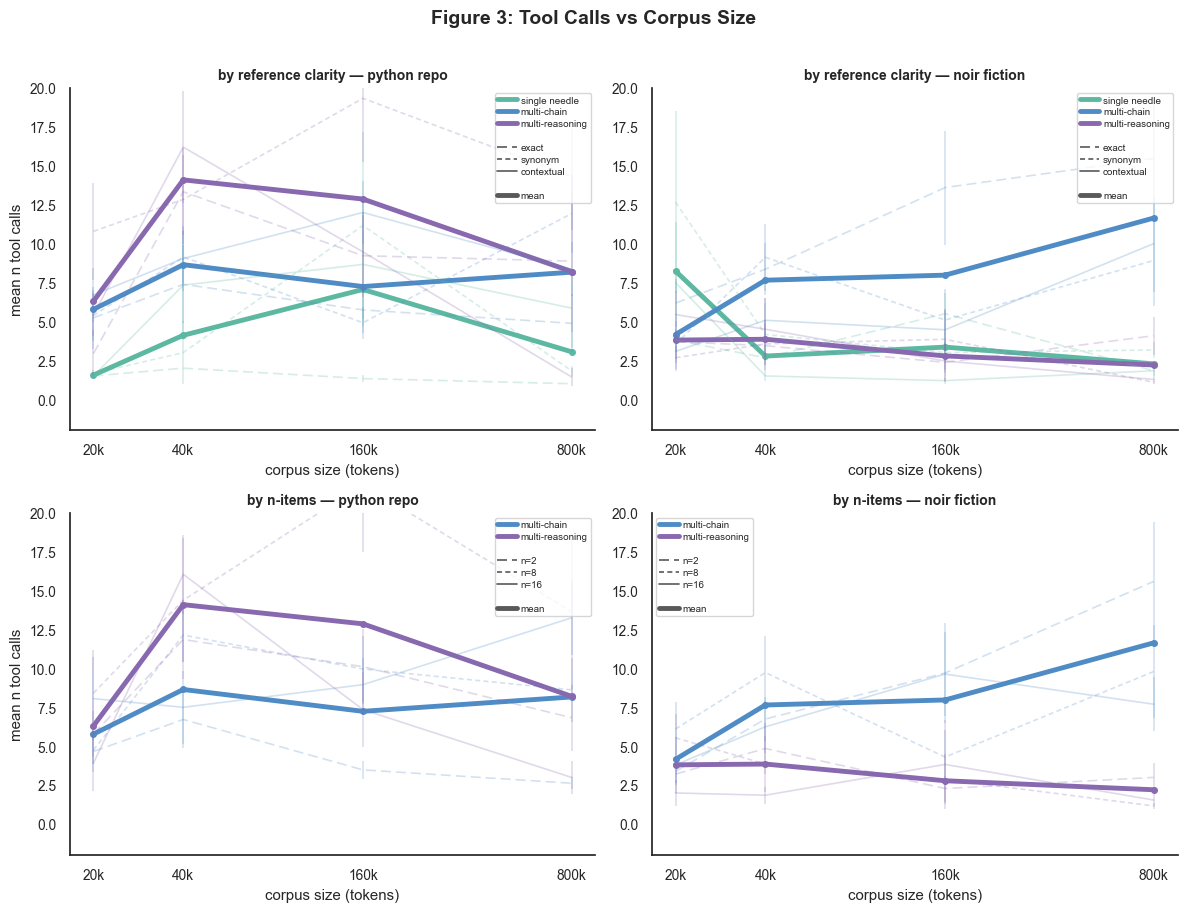

In [7]:
tool_cols = [c for c in df.columns if c.startswith("tool_")]
df["total_tool_calls"] = df[tool_cols].sum(axis=1)

max_tool_mean = df.groupby(["experiment_type", "corpus_token_count"])["total_tool_calls"].mean().max()
tool_ylim = (-2, int(np.ceil(max_tool_mean / 5) * 5) + 5)

fig3, axes3 = plt.subplots(2, 2, figsize=(12, 9))

# Row 1: by reference clarity
for col_idx, profile in enumerate(PROFILES):
    ax = axes3[0, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_tool_calls", EXP_ORDER, mode="clarity")
    set_corpus_xticks(ax)
    ax.set_ylim(tool_ylim)
    ax.set_title(f"by reference clarity — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("mean n tool calls")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="clarity")
    sns.despine(ax=ax)

# Row 2: by n-items
for col_idx, profile in enumerate(PROFILES):
    ax = axes3[1, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_tool_calls", ["multi_chain", "multi_reasoning"], mode="nitems")
    set_corpus_xticks(ax)
    ax.set_ylim(tool_ylim)
    ax.set_title(f"by n-items — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("mean n tool calls")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="nitems")
    sns.despine(ax=ax)

fig3.suptitle("Figure 3: Tool Calls vs Corpus Size", fontsize=14, fontweight="bold", y=1.01)
fig3.tight_layout()
plt.show()

## Figure 4: Tool Breakdown by Experiment Type

Percentage of tool calls by category for each experiment type. Subagent calls are opaque — each may trigger many internal tool calls not visible here.

*Single panel.* grep / glob / read / subagent / other.

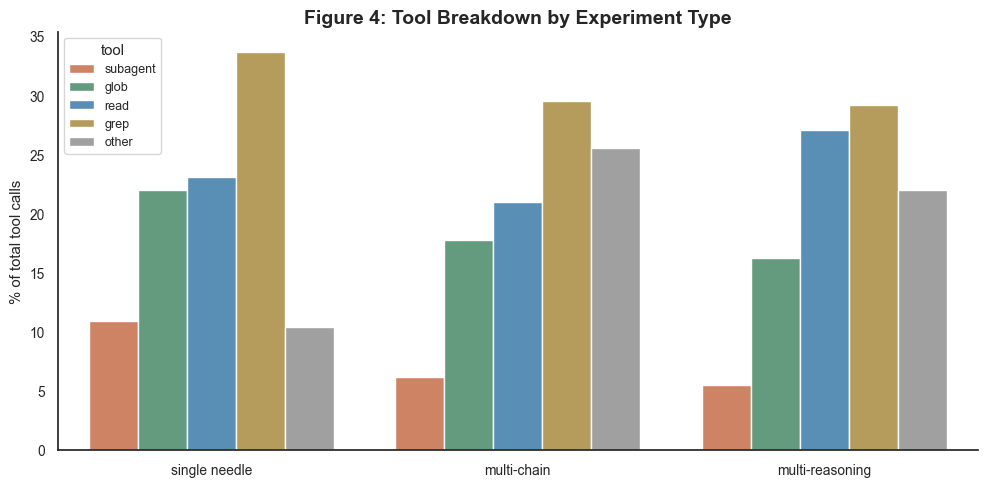

In [8]:
import pandas as pd

tool_cols = [c for c in df.columns if c.startswith("tool_")]
tool_names = [c.replace("tool_", "") for c in tool_cols]

tool_data = []
for exp_type in EXP_ORDER:
    sub = df[df["experiment_type"] == exp_type]
    means = {tn: sub[tc].mean() for tc, tn in zip(tool_cols, tool_names) if not np.isnan(sub[tc].mean())}
    total = sum(means.values())
    if total > 0:
        for tn, mean_val in means.items():
            tool_data.append({
                "experiment type": EXP_LABELS[exp_type],
                "tool": tn,
                "% of total calls": mean_val / total * 100,
            })

tool_df = pd.DataFrame(tool_data)

fig4, ax4 = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=tool_df, x="experiment type", y="% of total calls", hue="tool",
    palette=TOOL_PALETTE, ax=ax4,
)
ax4.set_title("Figure 4: Tool Breakdown by Experiment Type", fontsize=14, fontweight="bold")
ax4.legend(title="tool", fontsize=9)
ax4.set_xlabel("")
ax4.set_ylabel("% of total tool calls")
sns.despine(ax=ax4)
fig4.tight_layout()
plt.show()